In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Iris.csv')

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
print("Feature and their types:")
print(df.dtypes)

Feature and their types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


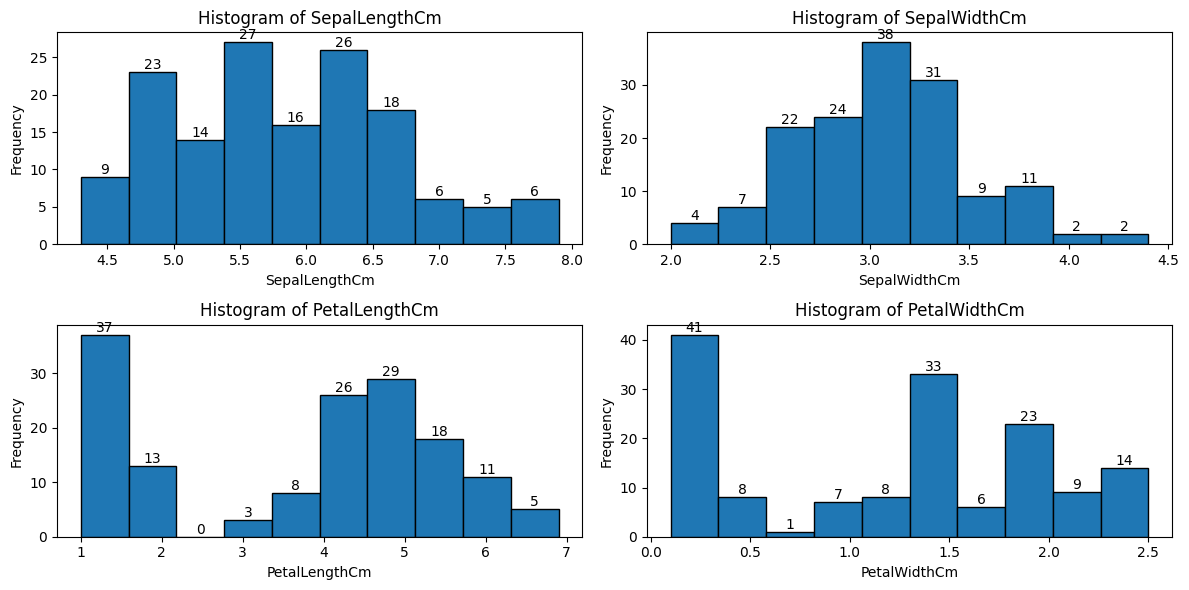

In [5]:
numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

plt.figure(figsize=(12, 6))

for i, column in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)

    counts, bins, patches = plt.hist(df[column], edgecolor="black")

    for count, patch in zip(counts, patches):
        plt.text(patch.get_x() + patch.get_width()/2, count, int(count),
                 ha='center', va='bottom')

    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

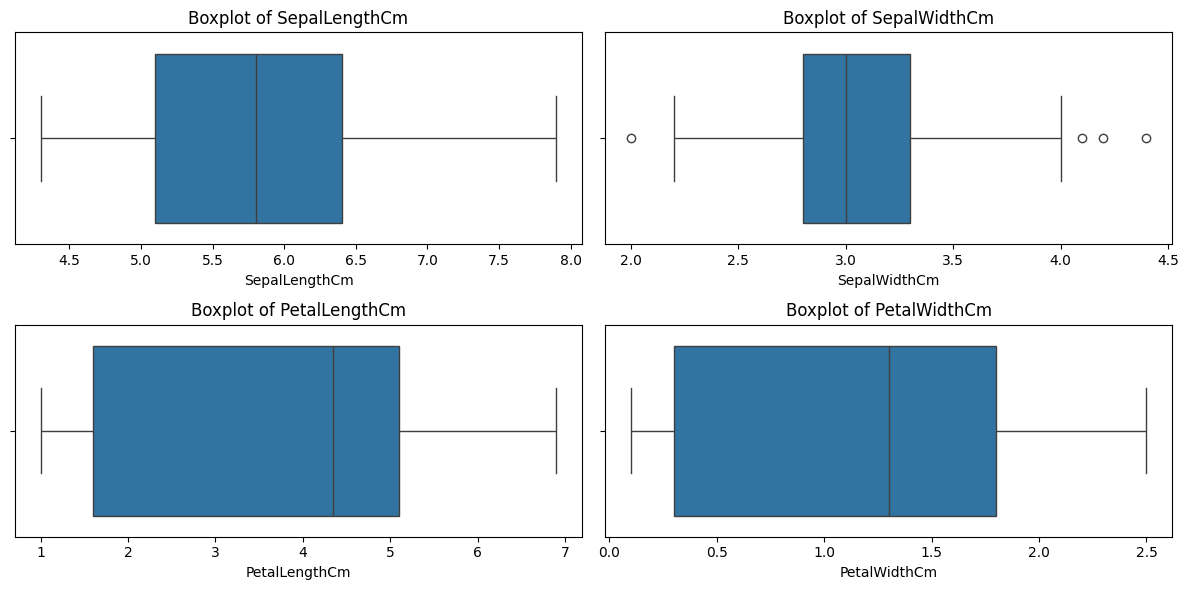

In [6]:
plt.figure(figsize=(12, 6))

for i, column in enumerate(numeric_cols):
    ax = plt.subplot(2, 2, i + 1)

    sns.boxplot(x=df[column], ax=ax)

    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

In [7]:
for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]

    print(f"\nFeature: {column}")
    print(f"Mean: {df[column].mean():.2f}")
    print(f"Median: {df[column].median():.2f}")
    print(f"Std Dev: {df[column].std():.2f}")

    if not outliers.empty:
        print("Outliers Detected: Yes")
        print("Outlier Values:", outliers.tolist())
    else:
        print("Outliers Detected: No")

    print("-" * 40)


Feature: SepalLengthCm
Mean: 5.84
Median: 5.80
Std Dev: 0.83
Outliers Detected: No
----------------------------------------

Feature: SepalWidthCm
Mean: 3.05
Median: 3.00
Std Dev: 0.43
Outliers Detected: Yes
Outlier Values: [4.4, 4.1, 4.2, 2.0]
----------------------------------------

Feature: PetalLengthCm
Mean: 3.76
Median: 4.35
Std Dev: 1.76
Outliers Detected: No
----------------------------------------

Feature: PetalWidthCm
Mean: 1.20
Median: 1.30
Std Dev: 0.76
Outliers Detected: No
----------------------------------------


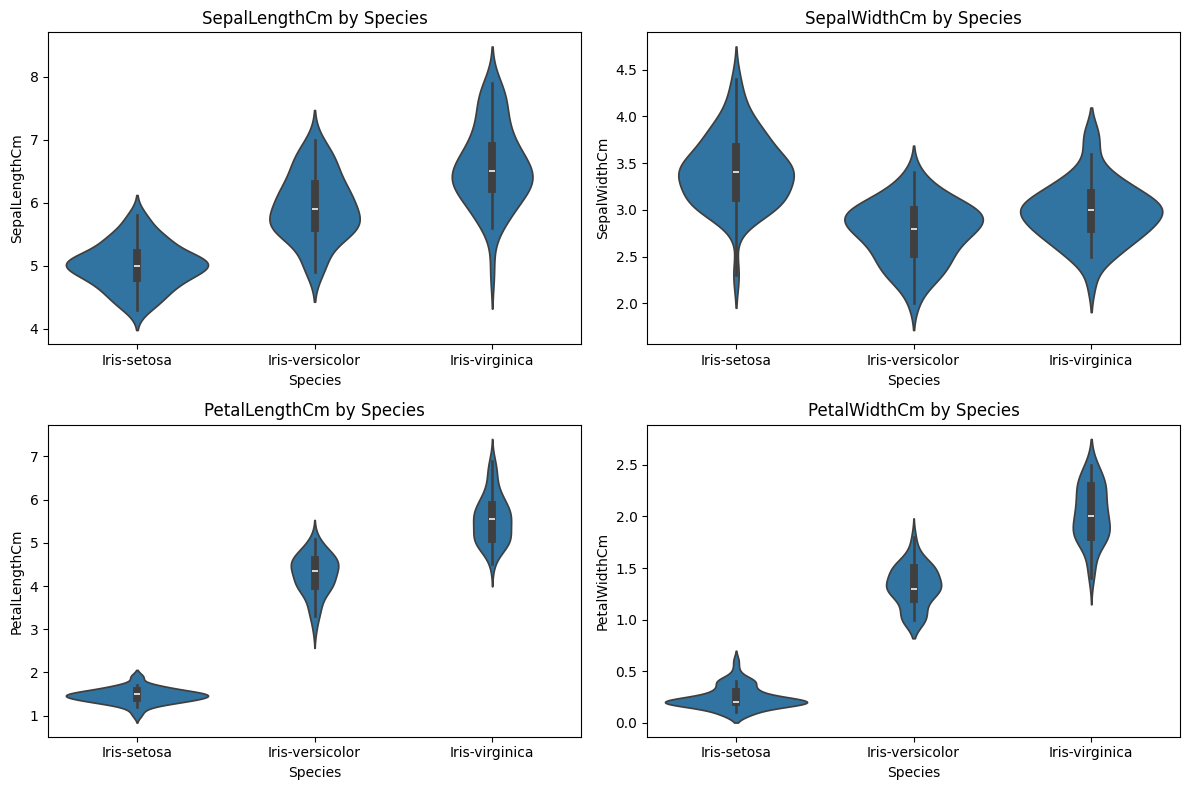

In [8]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)

    sns.violinplot(x=df["Species"], y=df[column])

    plt.title(f"{column} by Species")

plt.tight_layout()
plt.show()